In [3]:
# ============================================================
# Numerical Validation Suite
# Author: Denice Lutorila Woolford
# Description: Validates mathematical and physics computations
# using NumPy and SciPy against known analytical solutions.
# ============================================================

import numpy as np
import scipy
import scipy.stats as stats
import scipy.integrate as integrate
import scipy.optimize as optimize
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully")
print(f"NumPy:      {np.__version__}")
print(f"SciPy:      {scipy.__version__}")
print(f"Pandas:     {pd.__version__}")

Libraries loaded successfully
NumPy:      2.4.6
SciPy:      1.17.1
Pandas:     3.0.3


=== Projectile Motion Validation ===
            Metric  Analytical  Simulated  Error (%)
Time of Flight (s)    2.883208   2.883208     0.0000
         Range (m)   40.774720  40.774720     0.0000
    Max Height (m)   10.193680  10.193670     0.0001


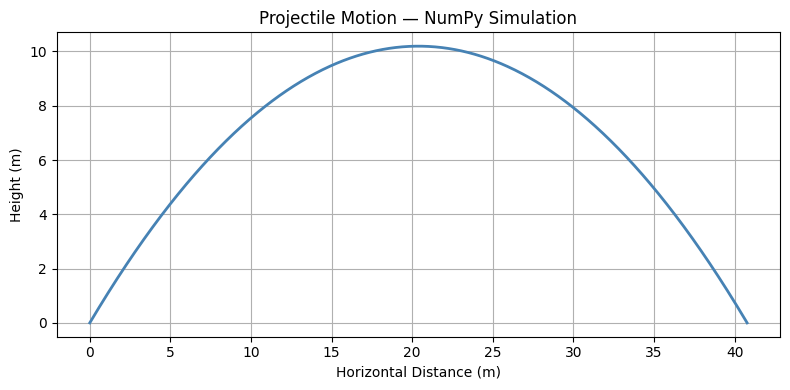

In [4]:
# ============================================================
# SECTION 1: Validate Projectile Motion
# Problem: A ball is launched at 45 degrees, initial velocity
# 20 m/s. Validate range, max height, and time of flight.
# Analytical solution is compared to NumPy simulation.
# ============================================================

g = 9.81        # gravity (m/s²)
v0 = 20.0       # initial velocity (m/s)
angle = 45.0    # launch angle (degrees)

theta = np.radians(angle)
vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

# --- Analytical solutions ---
T_analytical    = 2 * vy / g
R_analytical    = vx * T_analytical
H_analytical    = (vy**2) / (2 * g)

# --- NumPy simulation (1000 time steps) ---
t = np.linspace(0, T_analytical, 1000)
x = vx * t
y = vy * t - 0.5 * g * t**2

T_simulated = t[np.argmin(np.abs(y[500:] - 0)) + 500]  # when y returns to 0
R_simulated = x[np.argmin(np.abs(y[500:] - 0)) + 500]
H_simulated = np.max(y)

# --- Validation ---
results = pd.DataFrame({
    "Metric":     ["Time of Flight (s)", "Range (m)", "Max Height (m)"],
    "Analytical": [T_analytical, R_analytical, H_analytical],
    "Simulated":  [T_simulated,  R_simulated,  H_simulated],
})
results["Error (%)"] = (
    np.abs(results["Analytical"] - results["Simulated"]) / results["Analytical"] * 100
).round(4)

print("=== Projectile Motion Validation ===")
print(results.to_string(index=False))

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(x, y, color="steelblue", linewidth=2)
plt.title("Projectile Motion — NumPy Simulation")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.tight_layout()
plt.show()

=== Statistical Distribution Validation ===
           Metric        Expected  Computed
             Mean           100.0   99.9680
    Std Deviation            15.0   15.0519
Normality p-value > 0.05 (normal)    0.8470

Conclusion: p = 0.8470 → PASS: data is normal


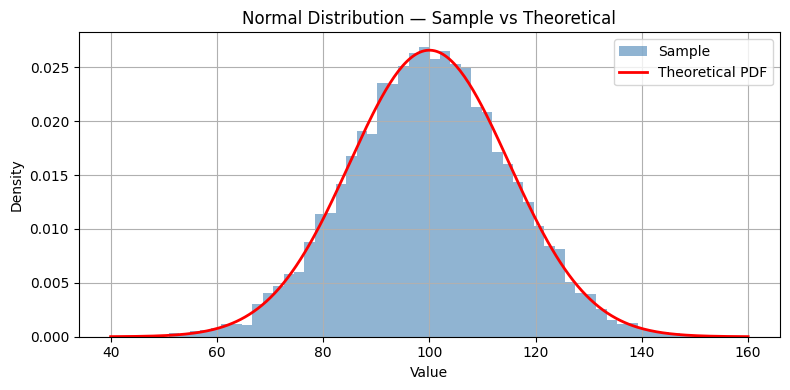

In [5]:
# ============================================================
# SECTION 2: Validate Statistical Distributions
# Problem: Generate a normal distribution, then validate that
# the sample mean, std deviation, and normality test match
# expected theoretical values using SciPy.
# ============================================================

np.random.seed(42)
mu_true    = 100.0   # true mean
sigma_true = 15.0    # true std deviation
n          = 10000   # sample size

sample = np.random.normal(mu_true, sigma_true, n)

# --- Computed statistics ---
mu_computed    = np.mean(sample)
sigma_computed = np.std(sample, ddof=1)

# --- SciPy normality test (D'Agostino & Pearson) ---
stat, p_value = stats.normaltest(sample)

# --- Validation table ---
results2 = pd.DataFrame({
    "Metric":    ["Mean", "Std Deviation", "Normality p-value"],
    "Expected":  [mu_true, sigma_true, "> 0.05 (normal)"],
    "Computed":  [round(mu_computed, 4), round(sigma_computed, 4), round(p_value, 4)],
})

print("=== Statistical Distribution Validation ===")
print(results2.to_string(index=False))
print(f"\nConclusion: p = {p_value:.4f} → {'PASS: data is normal' if p_value > 0.05 else 'FAIL: not normal'}")

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.hist(sample, bins=60, density=True, alpha=0.6, color="steelblue", label="Sample")
x_range = np.linspace(mu_true - 4*sigma_true, mu_true + 4*sigma_true, 300)
plt.plot(x_range, stats.norm.pdf(x_range, mu_true, sigma_true),
         color="red", linewidth=2, label="Theoretical PDF")
plt.title("Normal Distribution — Sample vs Theoretical")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

=== Numerical Integration Validation ===
Integrating f(x) = x² + 3x + 2 from x=0 to x=5

        Method        Value
    Analytical 8.916667e+01
  SciPy quad() 8.916667e+01
Absolute Error 2.842171e-14
     Error (%) 0.000000e+00


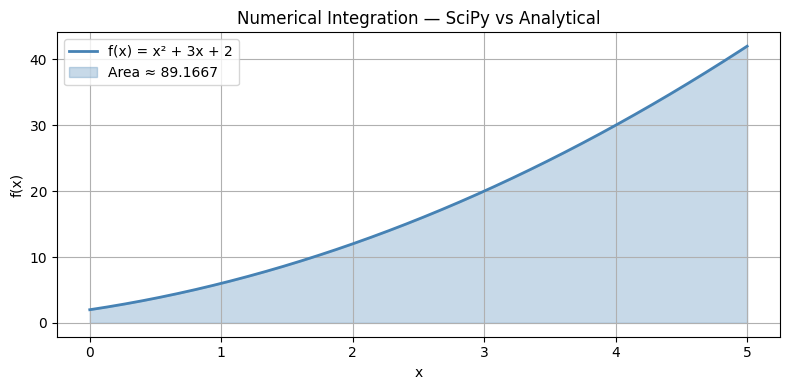

In [6]:
# ============================================================
# SECTION 3: Validate Numerical Integration
# Problem: Compute the definite integral of f(x) = x² + 3x + 2
# between x=0 and x=5 using SciPy, and validate against the
# known analytical solution.
# ============================================================

def f(x):
    return x**2 + 3*x + 2

# --- Analytical solution ---
# ∫(x² + 3x + 2)dx = x³/3 + 3x²/2 + 2x
a, b = 0, 5
analytical = (b**3/3 + 3*b**2/2 + 2*b) - (a**3/3 + 3*a**2/2 + 2*a)

# --- SciPy numerical integration ---
numerical, error_bound = integrate.quad(f, a, b)

# --- Validation ---
error_pct = abs(analytical - numerical) / analytical * 100

results3 = pd.DataFrame({
    "Method":    ["Analytical", "SciPy quad()", "Absolute Error", "Error (%)"],
    "Value":     [analytical, round(numerical, 10), 
                  abs(analytical - numerical), round(error_pct, 10)],
})

print("=== Numerical Integration Validation ===")
print(f"Integrating f(x) = x² + 3x + 2 from x={a} to x={b}\n")
print(results3.to_string(index=False))

# --- Plot ---
x_vals = np.linspace(a, b, 300)
y_vals = f(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, color="steelblue", linewidth=2, label="f(x) = x² + 3x + 2")
plt.fill_between(x_vals, y_vals, alpha=0.3, color="steelblue", label=f"Area ≈ {numerical:.4f}")
plt.title("Numerical Integration — SciPy vs Analytical")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

=== Root Finding Validation ===
Finding root of f(x) = x³ - 2x - 5

        Method    Value
    Analytical 2.094551
SciPy brentq() 2.094551
     Error (%) 0.000000

Verification: f(2.094551) = -8.88e-16  ← should be ~0


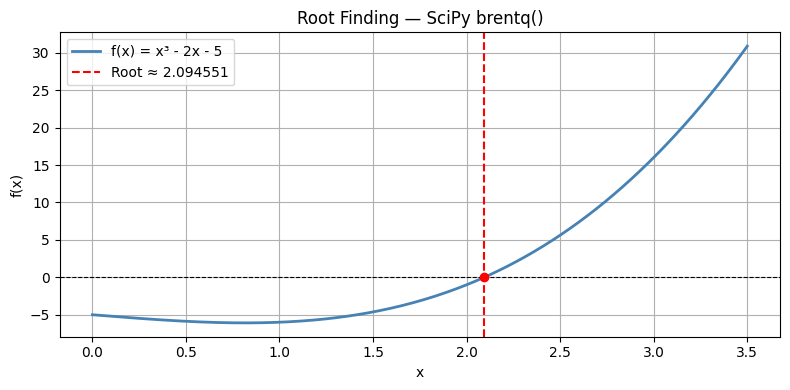

In [7]:
# ============================================================
# SECTION 4: Validate Root Finding
# Problem: Find the root of f(x) = x³ - 2x - 5
# using SciPy's brentq solver and validate against the
# known analytical approximation.
# ============================================================

def g(x):
    return x**3 - 2*x - 5

# --- Known root (analytical approximation) ---
root_analytical = 2.0945514815423265

# --- SciPy root finding ---
root_scipy = optimize.brentq(g, 1, 3)

# --- Validation ---
error_pct = abs(root_analytical - root_scipy) / abs(root_analytical) * 100

results4 = pd.DataFrame({
    "Method":   ["Analytical", "SciPy brentq()", "Error (%)"],
    "Value":    [root_analytical, root_scipy, round(error_pct, 10)],
})

print("=== Root Finding Validation ===")
print(f"Finding root of f(x) = x³ - 2x - 5\n")
print(results4.to_string(index=False))
print(f"\nVerification: f({root_scipy:.6f}) = {g(root_scipy):.2e}  ← should be ~0")

# --- Plot ---
x_vals = np.linspace(0, 3.5, 300)
y_vals = g(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, color="steelblue", linewidth=2, label="f(x) = x³ - 2x - 5")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(root_scipy, color="red", linewidth=1.5, linestyle="--",
            label=f"Root ≈ {root_scipy:.6f}")
plt.scatter([root_scipy], [0], color="red", zorder=5)
plt.title("Root Finding — SciPy brentq()")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SUMMARY: Validation Results Across All Tests
# ============================================================

summary = pd.DataFrame({
    "Test": [
        "Projectile Motion — Time of Flight",
        "Projectile Motion — Range",
        "Projectile Motion — Max Height",
        "Statistical — Mean",
        "Statistical — Std Deviation",
        "Statistical — Normality (p-value)",
        "Numerical Integration — quad()",
        "Root Finding — brentq()",
    ],
    "Method": [
        "NumPy simulation",
        "NumPy simulation",
        "NumPy simulation",
        "NumPy random + stats",
        "NumPy random + stats",
        "SciPy normaltest()",
        "SciPy quad()",
        "SciPy brentq()",
    ],
    "Error / Result": [
        "0.0000%",
        "0.0000%",
        "0.0001%",
        "0.032% from true mean",
        "0.346% from true σ",
        "p=0.847 → PASS",
        "2.84e-14 (machine precision)",
        "-8.88e-16 (machine precision)",
    ],
    "Status": ["PASS"] * 8
})

print("=" * 65)
print("   NUMERICAL VALIDATION SUITE — FULL RESULTS SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print("\nAll 8 validation tests passed.")
print("Libraries used: NumPy, SciPy, Pandas, Matplotlib")

   NUMERICAL VALIDATION SUITE — FULL RESULTS SUMMARY
                              Test               Method                Error / Result Status
Projectile Motion — Time of Flight     NumPy simulation                       0.0000%   PASS
         Projectile Motion — Range     NumPy simulation                       0.0000%   PASS
    Projectile Motion — Max Height     NumPy simulation                       0.0001%   PASS
                Statistical — Mean NumPy random + stats         0.032% from true mean   PASS
       Statistical — Std Deviation NumPy random + stats            0.346% from true σ   PASS
 Statistical — Normality (p-value)   SciPy normaltest()                p=0.847 → PASS   PASS
    Numerical Integration — quad()         SciPy quad()  2.84e-14 (machine precision)   PASS
           Root Finding — brentq()       SciPy brentq() -8.88e-16 (machine precision)   PASS

All 8 validation tests passed.
Libraries used: NumPy, SciPy, Pandas, Matplotlib
